
# Supervised BEATs: только голова (frozen backbone)

Клон `beats_ultrasound_bat_baseline.ipynb`: обучение **с нуля от BEATs_iter3.pt** (без resume finetune).


In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings(
    "ignore",
    message="`torch.nn.utils.weight_norm` is deprecated*",
    category=FutureWarning,
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ClearML и пути

Пути к данным и чекпоинтам, `.env`, device, **ClearML**


In [2]:
PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
sys.path.insert(0, str(PROJECT_DIR))

from beats_bat import (
    BEATsBatClassifier,
    build_beats_from_config,
    load_beats_checkpoint,
    waveform_to_beats_fbank,
    set_beats_trainable,
    beats_trainable_parameters,
    DEFAULT_N_FFT,
    DEFAULT_HOP_LENGTH,
)

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEATS_PRETRAINED = CHECKPOINT_DIR / "BEATs_iter3.pt"
BEST_CKPT = CHECKPOINT_DIR / "beats_bat_freeze_head_best.pt"
TRAIN_LOG_TXT = CHECKPOINT_DIR / "beats_bat_freeze_head_train_log.txt"

import logging
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env", override=False)

CLEARML_QUIET = os.environ.get("CLEARML_QUIET", "1").strip().lower() in ("1", "true", "yes")
CLEARML_UPLOAD_EACH_BEST = os.environ.get("CLEARML_UPLOAD_EACH_BEST", "0").strip().lower() in (
    "1", "true", "yes",
)


def setup_clearml_console(quiet: bool = True) -> None:
    if not quiet:
        return
    for name in ("clearml", "clearml.storage", "clearml.model", "clearml.Task"):
        logging.getLogger(name).setLevel(logging.WARNING)
    try:
        from clearml.storage.callbacks import ProgressReport

        def _no_tqdm(self):
            self._tqdm_init = True
            return None

        ProgressReport._get_tqdm = _no_tqdm
    except Exception:
        pass


setup_clearml_console(CLEARML_QUIET)

from clearml import OutputModel, Task

device = torch.device("mps")

# --- ClearML ---
RESUME_FROM_BEST = False
CLEARML_CONTINUE_LAST = False   # дописать метрики в ту же ClearML Task
CLEARML_TASK_ID = None         # явный ID задачи
CLEARML_PROJECT = "my project"
CLEARML_TASK_NAME = "beats_bat_freeze_head"

clearml_output_uri = os.environ.get("CLEARML_OUTPUT_URI", True)
if isinstance(clearml_output_uri, str) and clearml_output_uri.lower() in ("false", "0", "no", "none"):
    clearml_output_uri = False

_task_init_kw = dict(
    project_name=CLEARML_PROJECT,
    task_name=CLEARML_TASK_NAME,
    output_uri=clearml_output_uri,
    auto_resource_monitoring=False,
)
if CLEARML_TASK_ID:
    _task_init_kw["continue_last_task"] = CLEARML_TASK_ID
    _task_init_kw["reuse_last_task_id"] = CLEARML_TASK_ID
elif CLEARML_CONTINUE_LAST and RESUME_FROM_BEST:
    # train_model передаёт iteration=epoch 
    _task_init_kw["continue_last_task"] = 0
    _task_init_kw["reuse_last_task_id"] = True
else:
    _task_init_kw["reuse_last_task_id"] = False

clearml_task = Task.init(**_task_init_kw)
output_dest = clearml_task.get_output_destination() or ""
output_model = OutputModel(
    task=clearml_task,
    name="beats_bat_freeze_head",
    framework="pytorch",
)
if output_dest:
    output_model.set_upload_destination(output_dest)

if not CLEARML_QUIET:
    print("ClearML:", clearml_task.get_output_log_web_page())
print(
    "device:", device,
    "| quiet:", CLEARML_QUIET,
    "| upload each best:", CLEARML_UPLOAD_EACH_BEST,
    "| clearml continue:", (CLEARML_CONTINUE_LAST and RESUME_FROM_BEST) or bool(CLEARML_TASK_ID),
    "| clearml task:", clearml_task.id,
)


ClearML Task: created new task id=c9fcfb488ae94b7d975222ca3feb3573
ClearML results page: https://app.clear.ml/projects/6c3eac4aaa974ff39b83424d3f26990c/experiments/c9fcfb488ae94b7d975222ca3feb3573/output/log
device: mps | quiet: True | upload each best: False | clearml continue: False | clearml task: c9fcfb488ae94b7d975222ca3feb3573


# Аудио и crop

**192 kHz**, клип **2 с**. На train — energy-biased или random crop, на val — center crop. Затем waveform → uniform fbank для BEATs.


In [3]:
TARGET_SR = 192_000
CLIP_SEC = 2.0
N_FFT = DEFAULT_N_FFT
HOP_LENGTH = DEFAULT_HOP_LENGTH
# Полная временная ось fbank для 2 с 
TARGET_TIME_FRAMES = None

ENERGY_CROP_PROB = 0.7
ENERGY_CROP_CANDIDATES = 8
WAV_GAIN_JITTER_DB = 6.0


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def random_crop_or_pad(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if len(y) >= target_len:
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


def energy_biased_crop(
    y: np.ndarray, target_len: int, rng: np.random.Generator, n_candidates: int
) -> np.ndarray:
    if len(y) < target_len:
        return center_crop_or_pad(y, target_len)
    best_i0, best_e = 0, -1.0
    for _ in range(n_candidates):
        i0 = int(rng.integers(0, len(y) - target_len + 1))
        seg = y[i0 : i0 + target_len]
        e = float(np.mean(seg * seg))
        if e > best_e:
            best_e, best_i0 = e, i0
    return y[best_i0 : best_i0 + target_len]


def pick_train_crop(y: np.ndarray, target_len: int, rng: np.random.Generator) -> np.ndarray:
    if rng.random() < ENERGY_CROP_PROB:
        return energy_biased_crop(y, target_len, rng, ENERGY_CROP_CANDIDATES)
    return random_crop_or_pad(y, target_len, rng)


def maybe_gain_jitter(y: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    if WAV_GAIN_JITTER_DB <= 0:
        return y
    gain = 10.0 ** (float(rng.uniform(-WAV_GAIN_JITTER_DB, WAV_GAIN_JITTER_DB)) / 20.0)
    return (y * gain).astype(np.float32)


# Датасет (метаданные)

Загрузка CSV, пути к WAV, stratified split 85/15.


In [4]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]), axis=1
)
df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")

vc_train = train_df["species"].value_counts().sort_values()
print(
    f"Классы train: min={vc_train.min()} max={vc_train.max()} "
    f"ratio={vc_train.max() / max(vc_train.min(), 1):.2f}"
)
display(vc_train.head(8))


Train: 4348  Val: 768  Классов: 26
Классы train: min=133 max=170 ratio=1.28


species
LABL    133
COTO    142
NYMA    163
LASE    170
MYYU    170
MYSO    170
MYVO    170
PAHE    170
Name: count, dtype: int64

# Dataset

`BatWavBeatsFbankDataset`: WAV → crop → `waveform_to_beats_fbank` → `[T, 128]`.


In [5]:
class BatWavBeatsFbankDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.training = training
        self.rng = np.random.default_rng(RANDOM_SEED)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        if self.training:
            y = pick_train_crop(y, tgt, self.rng)
            y = maybe_gain_jitter(y, self.rng)
        else:
            y = center_crop_or_pad(y, tgt)
        wav = torch.from_numpy(np.ascontiguousarray(y, dtype=np.float32))
        fbank = waveform_to_beats_fbank(
            wav,
            float(TARGET_SR),
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            target_time_frames=TARGET_TIME_FRAMES,
        )
        return fbank.contiguous().float(), int(row["label"])


# DataLoader

`WeightedRandomSampler` на train; batch меньше из‑за длинного fbank (~751 кадров).


In [6]:
train_ds = BatWavBeatsFbankDataset(train_df, training=True)
val_ds = BatWavBeatsFbankDataset(val_df, training=False)

label_counts = train_df["label"].value_counts().sort_index()
inv_count = {lbl: 1.0 / cnt for lbl, cnt in label_counts.items()}
sample_weights = train_df["label"].map(inv_count).values
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(
        np.asarray(sample_weights, dtype=np.float64).copy(), dtype=torch.double
    ),
    num_samples=len(train_df),
    replacement=True,
)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

xb, yb = next(iter(train_loader))
print("fbank batch:", xb.shape, "labels:", yb.shape)


fbank batch: torch.Size([8, 751, 128]) labels: torch.Size([8])


# BEATs

Загрузка `BEATs_iter3.pt`, классификатор с отдельным LR для backbone и head.


In [7]:
_pretrained_ok = False
if BEATS_PRETRAINED.is_file():
    backbone, beats_cfg = load_beats_checkpoint(BEATS_PRETRAINED, map_location="cpu")
    _pretrained_ok = True
    print("pretrained:", BEATS_PRETRAINED)
else:
    backbone, beats_cfg = build_beats_from_config()
    print("WARNING: random init BEATs (нет", BEATS_PRETRAINED, ")")

backbone = backbone.to(device)
classifier = BEATsBatClassifier(
    backbone,
    num_classes=n_classes,
    encoder_dim=beats_cfg.encoder_embed_dim,
).to(device)

n_params = sum(p.numel() for p in classifier.parameters())
print(f"BEATs classifier params: {n_params:,}")
with torch.no_grad():
    print("logits:", classifier(xb.to(device)).shape)

TRAIN_HEAD_ONLY = True
UNFREEZE_LAST_N_LAYERS = 0
UNFREEZE_POST_EXTRACT = False
trainable_summary = set_beats_trainable(
    classifier.backbone,
    train_head_only=True,
)


n_trainable = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in classifier.parameters())
print("trainable params:", f"{n_trainable:,}", "/", f"{n_total:,}")
print("trainable summary:", trainable_summary)


pretrained: /Users/katterns/ITMO/Practice/checkpoints/BEATs_iter3.pt
BEATs classifier params: 90,333,322
logits: torch.Size([8, 26])
trainable params: 21,530 / 90,333,322
trainable summary: {'train_head_only': True, 'unfrozen_modules': []}


# Гиперпараметры

AdamW (разный LR backbone/head), `ReduceLROnPlateau`, label smoothing.


In [8]:
LR = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
MAX_EPOCHS = 40
PATIENCE = 10
LR_PLATEAU_PATIENCE = 5
LR_FACTOR = 0.5
LR_MIN = 1e-7
MAX_GRAD_NORM = 1.0

# RESUME_FROM_BEST — в ячейке ClearML (cell init). При resume: MAX_EPOCHS = абсолютный номер последней эпохи.
# При resume снизить LR (False — оставить BACKBONE_LR / HEAD_LR из optimizer)
RESUME_LOWER_LR = True
FINETUNE_BACKBONE_LR = 5e-6
FINETUNE_HEAD_LR = 1e-4

BACKBONE_LR = 1e-5 if _pretrained_ok else 5e-4
HEAD_LR = 3e-4

clearml_task.connect({
    "train_head_only": TRAIN_HEAD_ONLY,
    "unfreeze_last_n_layers": UNFREEZE_LAST_N_LAYERS,
    "unfreeze_post_extract_proj": UNFREEZE_POST_EXTRACT,
    "model": "beats_iter3",
    "clip_sec": CLIP_SEC,
    "energy_crop_prob": ENERGY_CROP_PROB,
    "batch_size": BATCH_SIZE,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "label_smoothing": LABEL_SMOOTHING,
    "pretrained_loaded": _pretrained_ok,
    "device": str(device),
    "resume_from_best": RESUME_FROM_BEST,
    "clearml_continue_last": CLEARML_CONTINUE_LAST,
})

loss_function = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
backbone_params = beats_trainable_parameters(classifier.backbone)
head_params = list(classifier.head.parameters())
optim_groups = []
if backbone_params:
    optim_groups.append({"params": backbone_params, "lr": BACKBONE_LR})
optim_groups.append({"params": head_params, "lr": HEAD_LR})
optimizer = optim.AdamW(
    optim_groups,
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PLATEAU_PATIENCE,
    min_lr=LR_MIN,
)


# Обучение

`evaluate`, `train_model`, early stopping. При `RESUME_FROM_BEST=True` и наличии `beats_bat_finetune_best.pt` — продолжение с **epoch+1** и лучшего macro-F1 из чекпоинта.


In [9]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    loss_epoch = 0.0
    num_samples = 0
    preds_list, targets_list = [], []

    for batch_x, target in val_loader:
        batch_x = batch_x.to(device)
        target = target.to(device)
        logits = model(batch_x)
        loss = loss_function(logits, target)
        num = logits.shape[0]
        loss_epoch += loss.item() * num
        num_samples += num
        preds_list.extend(logits.argmax(dim=-1).cpu().tolist())
        targets_list.extend(target.cpu().tolist())

    y_true = np.array(targets_list)
    y_pred = np.array(preds_list)
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_prec": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }
    return loss_epoch / max(num_samples, 1), metrics, y_true, y_pred


def _upload_checkpoint_to_clearml(epoch: int) -> str | None:
    if not output_dest:
        return None
    return output_model.update_weights(
        weights_filename=str(BEST_CKPT),
        upload_uri=output_dest or None,
        auto_delete_file=False,
        iteration=epoch,
    )


def _save_best_checkpoint(epoch, macro_f1, metrics):
    torch.save(
        {
            "classifier_state": classifier.state_dict(),
            "model_name": "beats_bat",
            "label2id": label2id,
            "id2label": {str(k): v for k, v in id2label.items()},
            "config": {
                "target_sr": TARGET_SR,
                "clip_sec": CLIP_SEC,
                "target_time_frames": TARGET_TIME_FRAMES,
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "pretrained_loaded": _pretrained_ok,
                "backbone_lr": BACKBONE_LR,
                "head_lr": HEAD_LR,
                "label_smoothing": LABEL_SMOOTHING,
                "energy_crop_prob": ENERGY_CROP_PROB,
                "train_head_only": TRAIN_HEAD_ONLY,
                "unfreeze_last_n_layers": UNFREEZE_LAST_N_LAYERS,
                "unfreeze_post_extract_proj": UNFREEZE_POST_EXTRACT,
            },
            "val_macro_f1": macro_f1,
            "val_weighted_f1": metrics["weighted_f1"],
            "val_balanced_acc": metrics["bal_acc"],
            "epoch": epoch,
        },
        BEST_CKPT,
    )
    model_uri = None
    if CLEARML_UPLOAD_EACH_BEST:
        model_uri = _upload_checkpoint_to_clearml(epoch)
    line = f"epoch={epoch} macro_f1={macro_f1:.4f} w_f1={metrics['weighted_f1']:.4f}\n"
    TRAIN_LOG_TXT.write_text(
        (TRAIN_LOG_TXT.read_text(encoding="utf-8") if TRAIN_LOG_TXT.exists() else "")
        + line,
        encoding="utf-8",
    )
    if CLEARML_QUIET:
        tqdm.write(f"saved {BEST_CKPT.name}  macro_f1={macro_f1:.4f}")
    else:
        msg = f"saved {BEST_CKPT}"
        if model_uri:
            msg += f"  ClearML: {model_uri}"
        tqdm.write(msg)


def _load_resume_checkpoint(model, ckpt_path: Path):
    """Загружает лучший чекпоинт; возвращает (start_epoch, best_macro_f1, best_epoch)."""
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Resume: нет файла {ckpt_path}")

    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt["classifier_state"], strict=True)

    ckpt_labels = ckpt.get("label2id") or {}
    if set(ckpt_labels.keys()) != set(label2id.keys()):
        tqdm.write("WARNING: label2id в чекпоинте отличается от текущего split")

    last_epoch = int(ckpt.get("epoch", 0))
    best_macro_f1 = float(ckpt.get("val_macro_f1", -1.0))
    start_epoch = last_epoch + 1
    return start_epoch, best_macro_f1, last_epoch


def _apply_finetune_lr():
    """Сниженный LR при дообучении с чекпоинта."""
    for pg in optimizer.param_groups:
        is_head = pg is optimizer.param_groups[-1]
        pg["lr"] = FINETUNE_HEAD_LR if is_head else FINETUNE_BACKBONE_LR
    tqdm.write(
        f"Finetune LR: backbone={FINETUNE_BACKBONE_LR:.2e} head={FINETUNE_HEAD_LR:.2e}"
    )


def train_model(
    model,
    num_epochs=40,
    max_grad_norm=1.0,
    resume_from_best: bool = False,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "val_acc": [],
    }
    best_macro_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    start_epoch = 1

    if resume_from_best:
        start_epoch, best_macro_f1, best_epoch = _load_resume_checkpoint(model, BEST_CKPT)
        if RESUME_LOWER_LR:
            _apply_finetune_lr()
        tqdm.write(
            f"Resume: {BEST_CKPT.name}  last_epoch={best_epoch}  "
            f"best_macro_f1={best_macro_f1:.4f}, epochs {start_epoch}..{num_epochs}"
        )
        if start_epoch > num_epochs:
            raise ValueError(
                f"Resume: start_epoch={start_epoch} > MAX_EPOCHS={num_epochs}. "
            )

    logger = clearml_task.get_logger()

    epoch_bar = tqdm(
        range(start_epoch, num_epochs + 1),
        desc="epochs",
        unit="epoch",
        initial=start_epoch - 1,
        total=num_epochs,
    )
    for epoch in epoch_bar:
        model.train()
        if TRAIN_HEAD_ONLY or not any(p.requires_grad for p in model.backbone.parameters()):
            model.backbone.eval()
        else:
            model.backbone.train()
        epoch_train_loss = 0.0
        epoch_train_n = 0

        batch_bar = tqdm(
            train_loader,
            desc=f"train e{epoch}",
            leave=False,
            unit="batch",
            position=1,
        )
        for batch_x, target in batch_bar:
            batch_x = batch_x.to(device)
            target = target.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = loss_function(logits, target)
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_n = batch_x.size(0)
            epoch_train_loss += loss.item() * batch_n
            epoch_train_n += batch_n
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        tr_loss = epoch_train_loss / max(epoch_train_n, 1)
        val_loss, metrics, y_true, y_pred = evaluate(model)
        lr_now = optimizer.param_groups[0]["lr"]
        macro_f1 = metrics["macro_f1"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(macro_f1)
        history["val_weighted_f1"].append(metrics["weighted_f1"])
        history["val_acc"].append(metrics["acc"])

        for name, val in metrics.items():
            logger.report_scalar("metrics", name, val, iteration=epoch)
        logger.report_scalar("loss", "train", tr_loss, iteration=epoch)
        logger.report_scalar("loss", "val", val_loss, iteration=epoch)
        logger.report_scalar("lr", "lr", lr_now, iteration=epoch)

        pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
        epoch_bar.set_postfix(macro_f1=f"{macro_f1:.4f}", val_loss=f"{val_loss:.4f}")
        tqdm.write(
            f"Epoch {epoch:02d}  lr={lr_now:.2e}  train={tr_loss:.4f}  val={val_loss:.4f}  "
            f"acc={metrics['acc']:.4f}  macro_f1={macro_f1:.4f}  "
            f"w_f1={metrics['weighted_f1']:.4f}  w_prec={metrics['weighted_prec']:.4f}  "
            f"top3={pred_top3}"
        )

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch
            epochs_no_improve = 0
            _save_best_checkpoint(epoch, macro_f1, metrics)
        else:
            epochs_no_improve += 1

        scheduler.step(macro_f1)

        if epochs_no_improve >= PATIENCE:
            tqdm.write("Early stopping.")
            break

    epoch_bar.close()
    if best_macro_f1 > 0 and output_dest and not CLEARML_UPLOAD_EACH_BEST:
        uri = _upload_checkpoint_to_clearml(best_epoch)
        if not CLEARML_QUIET and uri:
            tqdm.write(f"ClearML upload (final best, ep {best_epoch}): {uri}")
    tqdm.write(f"best macro_f1 (val): {best_macro_f1:.4f}")
    return model, history


# Запуск обучения


In [10]:
model, history = train_model(
    classifier,
    num_epochs=MAX_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    resume_from_best=RESUME_FROM_BEST,
)


epochs:   0%|          | 0/40 [00:00<?, ?epoch/s]

train e1:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 01  lr=3.00e-04  train=3.2224  val=3.1604  acc=0.0820  macro_f1=0.0372  w_f1=0.0377  w_prec=0.0369  top3={'NOISE': 385, 'MYLU': 105, 'TABR': 85}
saved beats_bat_freeze_head_best.pt  macro_f1=0.0372


train e2:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 02  lr=3.00e-04  train=3.1628  val=3.1213  acc=0.1016  macro_f1=0.0711  w_f1=0.0720  w_prec=0.1082  top3={'NOISE': 361, 'MYSO': 133, 'NYMA': 64}
saved beats_bat_freeze_head_best.pt  macro_f1=0.0711


...

Epoch 29  lr=7.50e-05  train=3.4174  val=3.1570  acc=0.1120  macro_f1=0.0906  w_f1=0.0900  w_prec=0.1831  top3={'COTO': 527, 'MYSE': 51, 'LANO': 46}


train e30:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 30  lr=7.50e-05  train=3.4194  val=3.0996  acc=0.1159  macro_f1=0.0806  w_f1=0.0799  w_prec=0.1834  top3={'COTO': 277, 'LABO': 169, 'EUMA': 133}


train e31:   0%|          | 0/544 [00:00<?, ?batch/s]

Epoch 31  lr=7.50e-05  train=3.4311  val=3.0335  acc=0.1224  macro_f1=0.1051  w_f1=0.1043  w_prec=0.1811  top3={'COTO': 414, 'LACI': 122, 'EPFU': 42}
Early stopping.
best macro_f1 (val): 0.1132


# Оценка на validation

Лучший чекпоинт, classification report и confusion matrix.


epoch: 21
macro F1: 0.11324040219948321
weighted F1: 0.11272390385422049
weighted precision: 0.16592301553675035
balanced acc: 0.13280503978779842
accuracy: 0.12890625

              precision    recall  f1-score   support

        ANPA       0.00      0.00      0.00        30
        COTO       0.05      0.64      0.09        25
        EPFU       0.46      0.20      0.28        30
        EUMA       0.17      0.50      0.26        30
        LABL       0.17      0.21      0.19        24
        LABO       0.00      0.00      0.00        30
        LACI       0.33      0.03      0.06        30
        LAIN       0.23      0.10      0.14        30
        LANO       0.76      0.53      0.63        30
        LASE       0.12      0.03      0.05        30
        MYCA       0.17      0.03      0.06        30
        MYCI       0.00      0.00      0.00        30
        MYEV       0.00      0.00      0.00        30
        MYGR       0.00      0.00      0.00        30
        MYLE       0

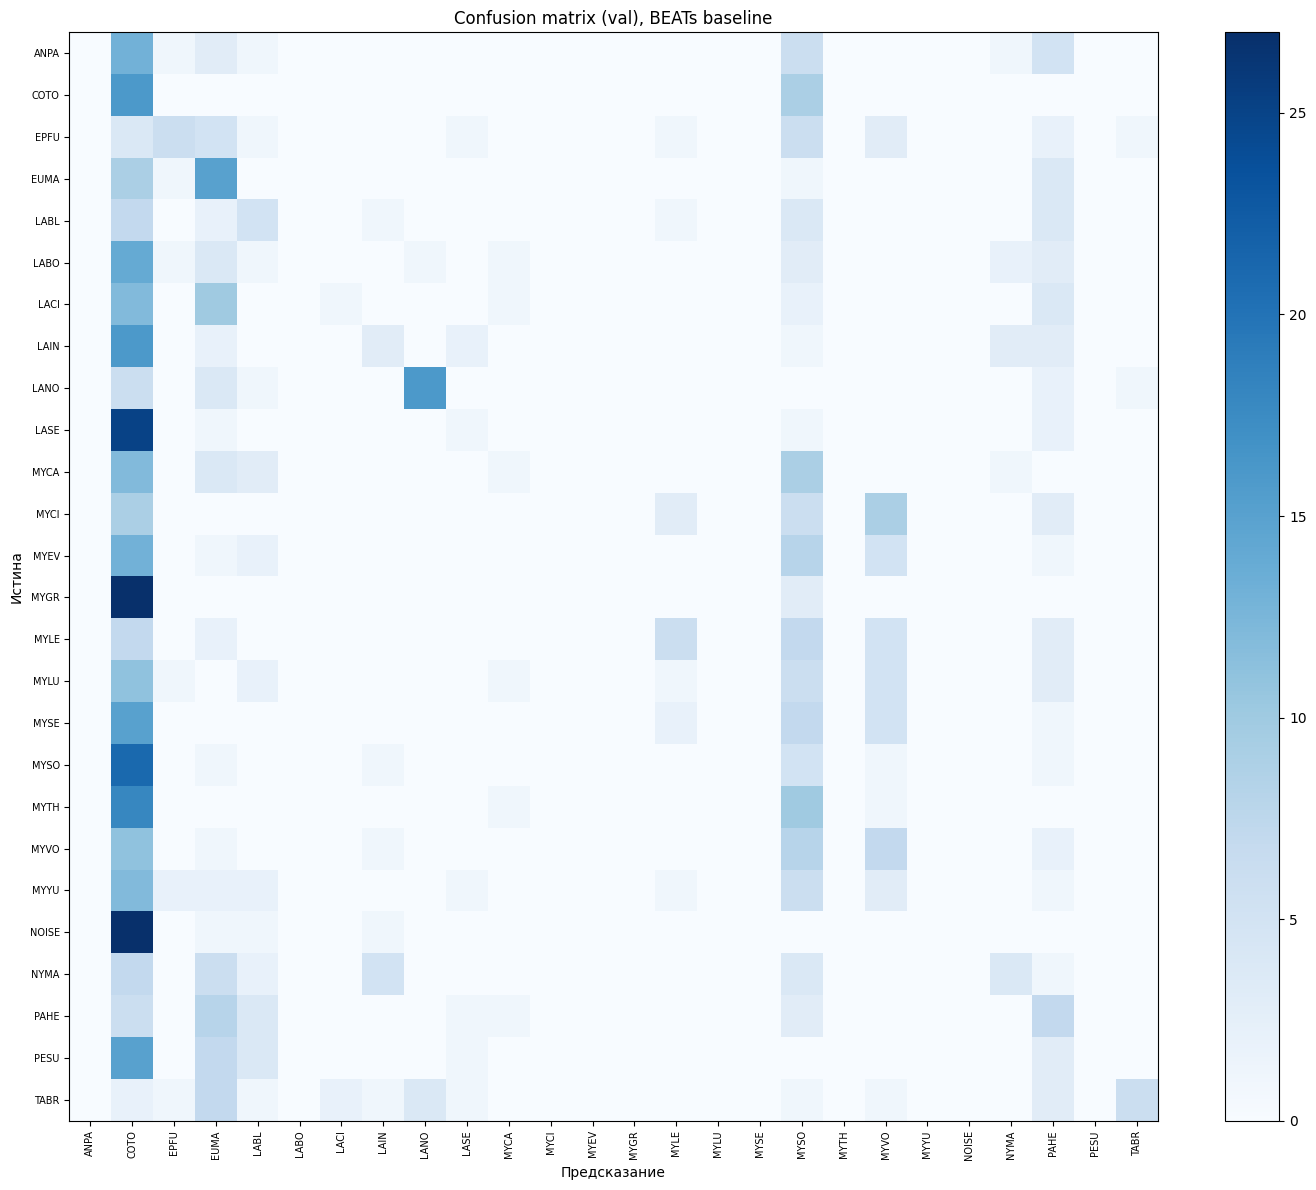

In [11]:
ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)

classifier.load_state_dict(ckpt["classifier_state"])

val_loss, metrics, y_true, y_pred = evaluate(classifier)
print("epoch:", ckpt.get("epoch"))
print("macro F1:", metrics["macro_f1"])
print("weighted F1:", metrics["weighted_f1"])
print("weighted precision:", metrics["weighted_prec"])
print("balanced acc:", metrics["bal_acc"])
print("accuracy:", metrics["acc"])
print()
print(classification_report(y_true, y_pred, target_names=species_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(species_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(species_sorted, fontsize=7)
ax.set_ylabel("Истина")
ax.set_xlabel("Предсказание")
ax.set_title("Confusion matrix (val), BEATs baseline")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
